# Malaysia Fish Landings & Economic Indicators
## Phase 1 — Data Preparation | Phase 2 — Variable Construction

**Research objective:** Examine the relationship and causality between Malaysia's fish landings and economic indicators (Fishing GDP, Food CPI, Food Trade).  
**This is NOT a forecasting study.** The goal is to identify whether fish landings lead or lag economic variables, and to what degree they are related.

**Study period:** 2018 Q1 – 2023 Q4 (n = 24 quarters)  
**Frequency:** Quarterly (all monthly sources aggregated to quarterly)

---
### Data Sources
| File | Variables Used |
|------|---------------|
| `fish_landings.csv` | National fish landings (monthly) |
| `gdp_qtr_real_supply_sub.csv` | Fishing sector GDP — sector `p1.4` (quarterly) |
| `cpi_2d.csv` | Food CPI div `01` — national food CPI |
| `trade_sitc_1d.csv` | Food exports/imports — SITC Section `0` (monthly) |
| `Fish_Weather_processed_data.csv` | Wind speed, humidity (monthly → controls) |

---
## Setup

In [17]:
# Cell P0.1 — Install dependencies
!pip install pandas numpy matplotlib seaborn scipy statsmodels -q

In [18]:
# Cell P0.2 — Imports and plot style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']
STUDY_START = pd.Period('2018Q1')
STUDY_END   = pd.Period('2023Q4')
OUTPUT_PATH = "/content/drive/MyDrive/FishStatPj/Paper3EcoandFish/outputs/"
print('Setup complete')

Setup complete


---
## Load Data from Google Drive

In [19]:
# Cell P0.3 — Mount Google Drive and load all datasets
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

base_path_eco  = "/content/drive/MyDrive/FishStatPj/Paper3EcoandFish/EcoData/"
base_path_fish = "/content/drive/MyDrive/FishStatPj/Paper3EcoandFish/"

fish_raw          = pd.read_csv(base_path_fish + "fish_landings.csv", parse_dates=['date'])
gdp_raw           = pd.read_csv(base_path_eco  + "gdp_qtr_real_supply_sub.csv", parse_dates=['date'])
cpi_raw           = pd.read_csv(base_path_eco  + "cpi_2d.csv", parse_dates=['date'])
trade_raw         = pd.read_csv(base_path_eco  + "trade_sitc_1d.csv", parse_dates=['date'])
weather_processed = pd.read_csv(base_path_fish + "Fish_Weather_processed_data.csv")

print("All datasets loaded successfully from Google Drive.")
print(f"  fish_raw:          {fish_raw.shape}")
print(f"  gdp_raw:           {gdp_raw.shape}")
print(f"  cpi_raw:           {cpi_raw.shape}")
print(f"  trade_raw:         {trade_raw.shape}")
print(f"  weather_processed: {weather_processed.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All datasets loaded successfully from Google Drive.
  fish_raw:          (1368, 4)
  gdp_raw:           (9779, 4)
  cpi_raw:           (4396, 3)
  trade_raw:         (3443, 4)
  weather_processed: (1008, 14)


---
# PHASE 1 — DATA PREPARATION
> Build a single quarterly dataset (2018 Q1 – 2023 Q4) with all variables on the same time index.

---
## 1.1 — Fish Landings (Monthly → Quarterly Sum)

In [20]:
# Cell P1.1 — National fish landings: monthly to quarterly
# state='Malaysia', coast='all' is the official national aggregate from DOSM
# Avoids double-counting state-level rows

fish_nat = fish_raw[
    (fish_raw['state'] == 'Malaysia') & (fish_raw['coast'] == 'all')
].copy()
fish_nat = fish_nat[
    (fish_nat['date'] >= '2018-01-01') & (fish_nat['date'] <= '2023-12-01')
].copy()

# Sum to quarterly — landings is a flow variable (cumulative over the period)
fish_nat['quarter'] = fish_nat['date'].dt.to_period('Q')
fish_qtr = fish_nat.groupby('quarter', as_index=False)['landings'].sum()

print(f"Monthly obs: {len(fish_nat)} | Quarterly obs: {len(fish_qtr)}")
print(f"Period: {fish_qtr.quarter.min()} to {fish_qtr.quarter.max()}")
print(f"Missing: {fish_qtr.isnull().sum().sum()}")

Monthly obs: 72 | Quarterly obs: 24
Period: 2018Q1 to 2023Q4
Missing: 0


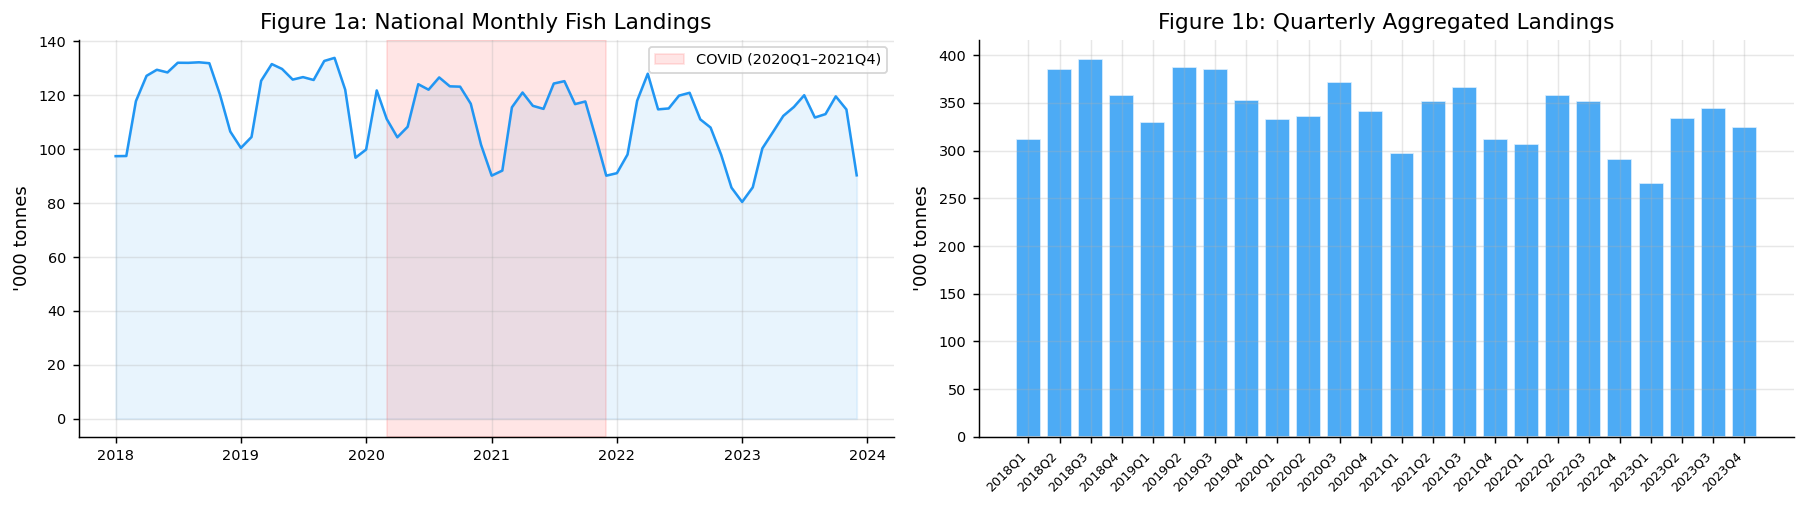

Saved: fig1_fish_landings.png


In [21]:
# Cell P1.1b — Figure 1: Fish landings trend (paper figure)
# This plot goes directly into the paper — shows trend and COVID disruption

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly
axes[0].plot(fish_nat['date'], fish_nat['landings']/1000,
             color=PALETTE[0], linewidth=1.4)
axes[0].fill_between(fish_nat['date'], fish_nat['landings']/1000,
                     alpha=0.10, color=PALETTE[0])
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'),
                alpha=0.10, color='red', label='COVID (2020Q1–2021Q4)')
axes[0].set_title("Figure 1a: National Monthly Fish Landings")
axes[0].set_ylabel("'000 tonnes")
axes[0].legend(fontsize=8)

# Quarterly
x = [str(q) for q in fish_qtr['quarter']]
axes[1].bar(x, fish_qtr['landings']/1000, color=PALETTE[0],
            alpha=0.80, edgecolor='white')
axes[1].set_title("Figure 1b: Quarterly Aggregated Landings")
axes[1].set_ylabel("'000 tonnes")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "fig1_fish_landings.png", bbox_inches='tight')
plt.show()
print("Saved: fig1_fish_landings.png")

## 1.2 — Fishing GDP (Quarterly, Sector p1.4)

In [22]:
# Cell P1.2 — Extract Fishing sector GDP (p1.4) from quarterly subsector data
# p1.4 = Fishing (confirmed via DOSM lookup table)
# p0   = Total GDP (for share calculation)
# Using 'abs' series = real RM million values

gdp_abs = gdp_raw[gdp_raw['series'] == 'abs'].copy()

def extract_sector(code, label):
    df = gdp_abs[gdp_abs['sector'] == code][['date','value']].copy()
    df.columns = ['date', label]
    df['quarter'] = df['date'].dt.to_period('Q')
    df = df[(df['quarter'] >= STUDY_START) & (df['quarter'] <= STUDY_END)]
    return df.sort_values('quarter').reset_index(drop=True)

gdp_fishing = extract_sector('p1.4', 'gdp_fishing')
gdp_total   = extract_sector('p0',   'gdp_total')

print(f"Fishing GDP obs: {len(gdp_fishing)}")
print(f"Period: {gdp_fishing.quarter.min()} to {gdp_fishing.quarter.max()}")

# GDP share check (for Table 1 footnote / in-text reference)
merged_g = gdp_fishing.merge(gdp_total, on='quarter')
merged_g['fish_pct'] = (merged_g['gdp_fishing'] / merged_g['gdp_total']) * 100
print(f"\nFishing GDP share of total GDP — Mean: {merged_g.fish_pct.mean():.3f}% | Range: {merged_g.fish_pct.min():.3f}%–{merged_g.fish_pct.max():.3f}%")
print("(Small share is expected and consistent with literature ~0.5-1%)")

Fishing GDP obs: 24
Period: 2018Q1 to 2023Q4

Fishing GDP share of total GDP — Mean: 0.815% | Range: 0.680%–1.072%
(Small share is expected and consistent with literature ~0.5-1%)


## 1.3 — Food CPI (National Aggregate — Division '01')

**Academic justification for using National Aggregate (Division '01'):**  
DOSM's CPI dataset includes a national aggregate for specific divisions. Division '01' directly represents the National Food and Non-Alcoholic Beverages CPI. This is the preferred measure as it reflects national price dynamics without needing a proxy. This is noted explicitly in the methods section.

In [23]:
# Cell P1.3 — Food CPI: National aggregate (Division '01')
# Division '01' = Food and Non-Alcoholic Beverages (COICOP classification)

# Filter for Division '01' (National Food CPI)
cpi_nat = cpi_raw[
    (cpi_raw['division'] == '01')
].copy() # Keep .copy() for safety

# Filter by study period and rename column
cpi_nat = cpi_nat[
    (cpi_nat['date'] >= '2018-01-01') & (cpi_nat['date'] <= '2023-12-01')
][['date','index']].rename(columns={'index': 'cpi_food'})

# Quarterly mean — CPI is a stock/index variable, mean of monthly values
# gives the average price level during the quarter (standard practice)
cpi_nat['quarter'] = cpi_nat['date'].dt.to_period('Q')
cpi_qtr = cpi_nat.groupby('quarter', as_index=False)['cpi_food'].mean()

print(f"CPI obs: {len(cpi_qtr)}")
print(f"Period: {cpi_qtr.quarter.min()} to {cpi_qtr.quarter.max()}")
print(f"Range: {cpi_qtr.cpi_food.min():.2f} to {cpi_qtr.cpi_food.max():.2f} (base 2010=100)")
print(f"\nNote: Using national food CPI (Division '01').")

CPI obs: 24
Period: 2018Q1 to 2023Q4
Range: 130.17 to 152.87 (base 2010=100)

Note: Using national food CPI (Division '01').


## 1.4 — Food Trade (Monthly → Quarterly Sum)

In [24]:
# Cell P1.4 — Food trade: SITC Section 0 (Food and live animals)
# Section '0' includes fish and fish products embedded in broader food category
# This is the highest-frequency available proxy for fisheries trade activity

trade_food = trade_raw[trade_raw['section'] == '0'].copy()
trade_food = trade_food[
    (trade_food['date'] >= '2018-01-01') & (trade_food['date'] <= '2023-12-01')
].copy()
trade_food['trade_balance'] = trade_food['exports'] - trade_food['imports']

# Quarterly sum — trade is a flow variable
trade_food['quarter'] = trade_food['date'].dt.to_period('Q')
trade_qtr = trade_food.groupby('quarter', as_index=False)[
    ['exports','imports','trade_balance']
].sum()
trade_qtr.columns = ['quarter','food_exports','food_imports','food_trade_balance']

# Convert to RM million for readability
for c in ['food_exports','food_imports','food_trade_balance']:
    trade_qtr[c] = trade_qtr[c] / 1e6

print(f"Trade obs: {len(trade_qtr)}")
deficit_q = (trade_qtr.food_trade_balance < 0).sum()
print(f"Food trade deficit quarters: {deficit_q}/{len(trade_qtr)}")
print("Note: Malaysia is a net food importer — this is a meaningful descriptive finding")

Trade obs: 24
Food trade deficit quarters: 24/24
Note: Malaysia is a net food importer — this is a meaningful descriptive finding


## 1.5 — Weather Controls (Monthly → Quarterly Mean)

In [25]:
# Cell P1.5 — Weather: national mean of wind_speed and humidity
# Retained variables (theoretical basis):
#   wind_speed → directly constrains fishing effort (storm/monsoon conditions)
#   humidity   → proxy for monsoon season intensity
# Dropped: temperature, pressure, dew_point, wind_chill, UV (multicollinear, weaker theory)

weather_processed['date'] = pd.to_datetime(
    weather_processed['year_month'], format='%Y-%m')

weather_nat = weather_processed.groupby('date', as_index=False)[
    ['wind_speed','humidity']
].mean()
weather_nat = weather_nat[
    (weather_nat['date'] >= '2018-01-01') & (weather_nat['date'] <= '2023-12-01')
]

# Quarterly mean — weather is a condition (stock), not a flow
weather_nat['quarter'] = weather_nat['date'].dt.to_period('Q')
weather_qtr = weather_nat.groupby('quarter', as_index=False)[
    ['wind_speed','humidity']
].mean()

print(f"Weather obs: {len(weather_qtr)}")
print(f"Wind speed — Mean: {weather_qtr.wind_speed.mean():.2f} m/s  |  Range: {weather_qtr.wind_speed.min():.2f}–{weather_qtr.wind_speed.max():.2f}")
print(f"Humidity   — Mean: {weather_qtr.humidity.mean():.2f}%      |  Range: {weather_qtr.humidity.min():.2f}–{weather_qtr.humidity.max():.2f}")

Weather obs: 24
Wind speed — Mean: 5.18 m/s  |  Range: 3.78–7.06
Humidity   — Mean: 83.33%      |  Range: 80.12–86.22


## 1.6 — Merge into Master Dataset

In [26]:
# Cell P1.6 — Inner merge on 'quarter' — all variables aligned to same time index
master = fish_qtr.copy()
master = master.merge(gdp_fishing[['quarter','gdp_fishing']], on='quarter', how='inner')
master = master.merge(cpi_qtr,    on='quarter', how='inner')
master = master.merge(trade_qtr[['quarter','food_exports','food_imports',
                                  'food_trade_balance']], on='quarter', how='inner')
master = master.merge(weather_qtr, on='quarter', how='inner')
master = master.sort_values('quarter').reset_index(drop=True)

print(f"Observations: {len(master)}")
print(f"Period: {master.quarter.min()} to {master.quarter.max()}")
print(f"Missing values: {master.isnull().sum().sum()}")

if master.isnull().sum().sum() == 0:
    print("Dataset is complete — no missing values")
else:
    print("WARNING: missing values detected")
    print(master.isnull().sum())

Observations: 24
Period: 2018Q1 to 2023Q4
Missing values: 0
Dataset is complete — no missing values


---
# PHASE 2 — VARIABLE CONSTRUCTION
> Transform raw levels into economically meaningful variables.  
> This step prepares variables for stationarity testing and causality analysis — not for prediction.

---
## 2.1 — Transformations

In [27]:
# Cell P2.1 — Create all transformed variables
df = master.copy()

# ── Log levels ──────────────────────────────────────────────────
# Compresses scale, reduces heteroscedasticity, enables elasticity interpretation
df['ln_landings']     = np.log(df['landings'])
df['ln_gdp_fishing']  = np.log(df['gdp_fishing'])
df['ln_cpi_food']     = np.log(df['cpi_food'])
df['ln_food_exports'] = np.log(df['food_exports'])
df['ln_food_imports'] = np.log(df['food_imports'])

# ── YoY growth rates: pct_change(4) for quarterly data ─────────
# Lag-4 naturally removes seasonality from quarterly series
# This is standard in Bank Negara / DOSM publications for Malaysian macro data
df['g_landings']     = df['landings'].pct_change(4)     * 100
df['g_gdp_fishing']  = df['gdp_fishing'].pct_change(4)  * 100
df['g_cpi_food']     = df['cpi_food'].pct_change(4)     * 100  # = food inflation YoY
df['g_food_exports'] = df['food_exports'].pct_change(4) * 100
df['g_food_imports'] = df['food_imports'].pct_change(4) * 100

# ── QoQ log-differences: used as first-differenced series in VAR ─
# If ln(Xt) is non-stationary I(1), then dln(Xt) = ln(Xt) - ln(Xt-1) is I(0)
for raw, new in [
    ('ln_landings',    'dln_landings'),
    ('ln_gdp_fishing', 'dln_gdp_fishing'),
    ('ln_cpi_food',    'dln_cpi_food'),
    ('ln_food_exports','dln_food_exports'),
    ('ln_food_imports','dln_food_imports'),
]:
    df[new] = df[raw].diff(1)

# ── COVID structural break dummy ────────────────────────────────
# 2020Q1–2021Q4: MCO began March 2020; major restrictions ended Dec 2021
df['covid'] = df['quarter'].apply(
    lambda q: 1 if pd.Period('2020Q1') <= q <= pd.Period('2021Q4') else 0)

# ── Seasonal dummies (Q1 = base / reference quarter) ───────────
df['q_num'] = df['quarter'].apply(lambda q: q.quarter)
df['Q2'] = (df['q_num'] == 2).astype(int)
df['Q3'] = (df['q_num'] == 3).astype(int)
df['Q4'] = (df['q_num'] == 4).astype(int)

print("Transformations complete:")
print("  ln_*   = Natural log (log-level)")
print("  g_*    = YoY growth rate % (lag-4, seasonality-adjusted)")
print("  dln_*  = QoQ log-difference (first difference of ln, for VAR)")
print("  covid  = Structural break dummy (2020Q1–2021Q4 = 1)")
print("  Q2,Q3,Q4 = Seasonal dummies (Q1 omitted as base)")
print(f"\nDataset shape: {df.shape}")
print("Note: g_* and dln_* rows 0–3 are NaN — expected from lag construction")

Transformations complete:
  ln_*   = Natural log (log-level)
  g_*    = YoY growth rate % (lag-4, seasonality-adjusted)
  dln_*  = QoQ log-difference (first difference of ln, for VAR)
  covid  = Structural break dummy (2020Q1–2021Q4 = 1)
  Q2,Q3,Q4 = Seasonal dummies (Q1 omitted as base)

Dataset shape: (24, 29)
Note: g_* and dln_* rows 0–3 are NaN — expected from lag construction


## 2.2 — Descriptive Statistics (Tables for Paper)

In [28]:
# Cell P2.2 — Table 1 and Table 2 (copy directly into paper)

# Table 1: Level variables
level_vars   = ['landings','gdp_fishing','cpi_food','food_exports','food_imports',
                'wind_speed','humidity']
level_labels = ['Fish Landings (000 t)', 'Fishing GDP (RM mn)', 'Food CPI (2010=100)',
                'Food Exports (RM mn)', 'Food Imports (RM mn)',
                'Wind Speed (m/s)', 'Humidity (%)']

t1 = df[level_vars].copy()
t1['landings'] = t1['landings'] / 1000  # convert to 000 tonnes

tbl1 = t1.describe().T
tbl1.index = level_labels
tbl1 = tbl1[['mean','std','min','50%','max']].round(2)
tbl1.columns = ['Mean','Std Dev','Min','Median','Max']

print("Table 1: Descriptive Statistics — Level Variables (2018Q1–2023Q4, n=24)")
print("="*85)
print(tbl1.to_string())
print("="*85)
print("Notes: Landings in 000 tonnes. Fishing GDP & Trade in real RM million.")
print("       Food CPI: W.P. Kuala Lumpur, COICOP Division 01, base 2010=100.")

# Table 2: Growth rate variables
growth_vars   = ['g_landings','g_gdp_fishing','g_cpi_food','g_food_exports','g_food_imports']
growth_labels = ['Landings Growth (YoY%)', 'Fishing GDP Growth (YoY%)',
                 'Food Inflation (YoY%)', 'Food Export Growth (YoY%)',
                 'Food Import Growth (YoY%)']

tbl2 = df[growth_vars].dropna().describe().T
tbl2.index = growth_labels
tbl2 = tbl2[['mean','std','min','50%','max']].round(3)
tbl2.columns = ['Mean','Std Dev','Min','Median','Max']

print("\nTable 2: Descriptive Statistics — YoY Growth Rates (2019Q1–2023Q4, n=20)")
print("="*85)
print(tbl2.to_string())
print("="*85)
print("Note: First 4 observations excluded due to lag-4 construction.")

Table 1: Descriptive Statistics — Level Variables (2018Q1–2023Q4, n=24)
                           Mean  Std Dev       Min    Median       Max
Fish Landings (000 t)    341.59    32.85    266.57    343.20    396.30
Fishing GDP (RM mn)     2913.40   328.51   2511.00   2798.62   3706.00
Food CPI (2010=100)      138.81     7.67    130.17    135.75    152.87
Food Exports (RM mn)    9550.69  1573.30   7412.34   9078.78  12876.59
Food Imports (RM mn)   15632.09  2949.63  12143.00  14330.11  21235.18
Wind Speed (m/s)           5.18     0.98      3.78      5.05      7.06
Humidity (%)              83.33     1.67     80.12     83.47     86.22
Notes: Landings in 000 tonnes. Fishing GDP & Trade in real RM million.
       Food CPI: W.P. Kuala Lumpur, COICOP Division 01, base 2010=100.

Table 2: Descriptive Statistics — YoY Growth Rates (2019Q1–2023Q4, n=20)
                            Mean  Std Dev     Min  Median     Max
Landings Growth (YoY%)    -2.474    6.244 -13.191  -2.418  11.304
Fishing GDP 

## 2.3 — Growth Rate Time Series (Figure for Paper)

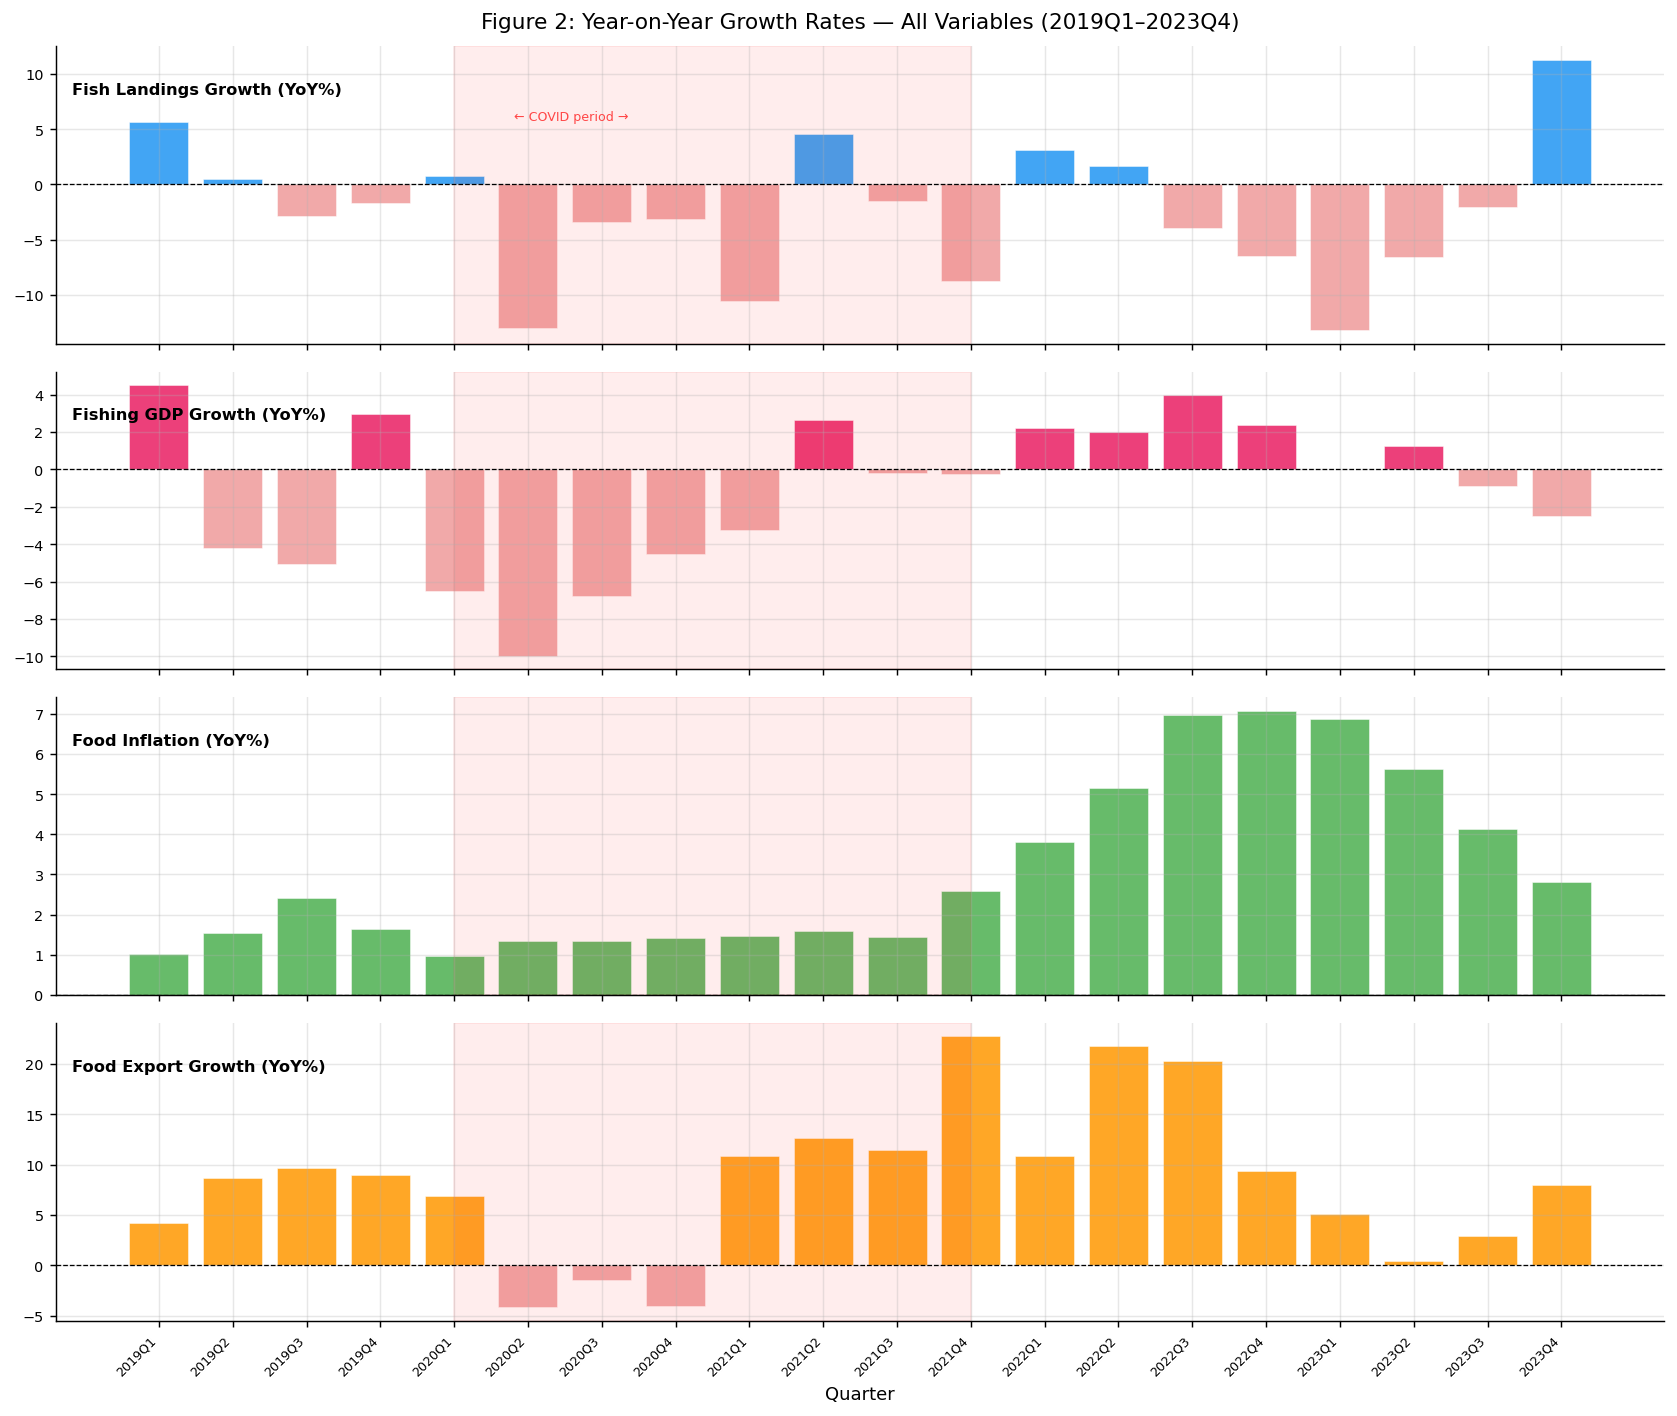

Saved: fig2_growth_rates.png


In [29]:
# Cell P2.3 — Figure 2: YoY growth rates — visual co-movement check
# This is Figure 2 in the paper. Key observations from this plot:
#   - COVID disruption visible as sharp negative bars (2020Q1-2021Q4)
#   - Weak co-movement between landings growth and fishing GDP growth
#   - Food inflation (g_cpi_food) is persistently positive throughout

df_g = df.dropna(subset=['g_landings']).copy()
x = [str(q) for q in df_g['quarter']]

plot_cfg = [
    ('g_landings',     'Fish Landings Growth (YoY%)',  PALETTE[0]),
    ('g_gdp_fishing',  'Fishing GDP Growth (YoY%)',    PALETTE[1]),
    ('g_cpi_food',     'Food Inflation (YoY%)',         PALETTE[2]),
    ('g_food_exports', 'Food Export Growth (YoY%)',     PALETTE[3]),
]

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

for ax, (col, label, color) in zip(axes, plot_cfg):
    vals = df_g[col].values
    bar_cols = [color if v >= 0 else '#ef9a9a' for v in vals]
    ax.bar(x, vals, color=bar_cols, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axvspan('2020Q1', '2021Q4', alpha=0.07, color='red')
    ax.text(0.01, 0.88, label, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')

axes[0].set_title(
    "Figure 2: Year-on-Year Growth Rates — All Variables (2019Q1–2023Q4)",
    fontsize=12, pad=10)
axes[0].annotate('← COVID period →', xy=(0.285, 0.75),
                 xycoords='axes fraction', fontsize=7, color='red', alpha=0.7)
axes[-1].set_xlabel('Quarter')
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + "fig2_growth_rates.png", bbox_inches='tight')
plt.show()
print("Saved: fig2_growth_rates.png")

## 2.4 — Correlation Analysis (Table and Figure for Paper)

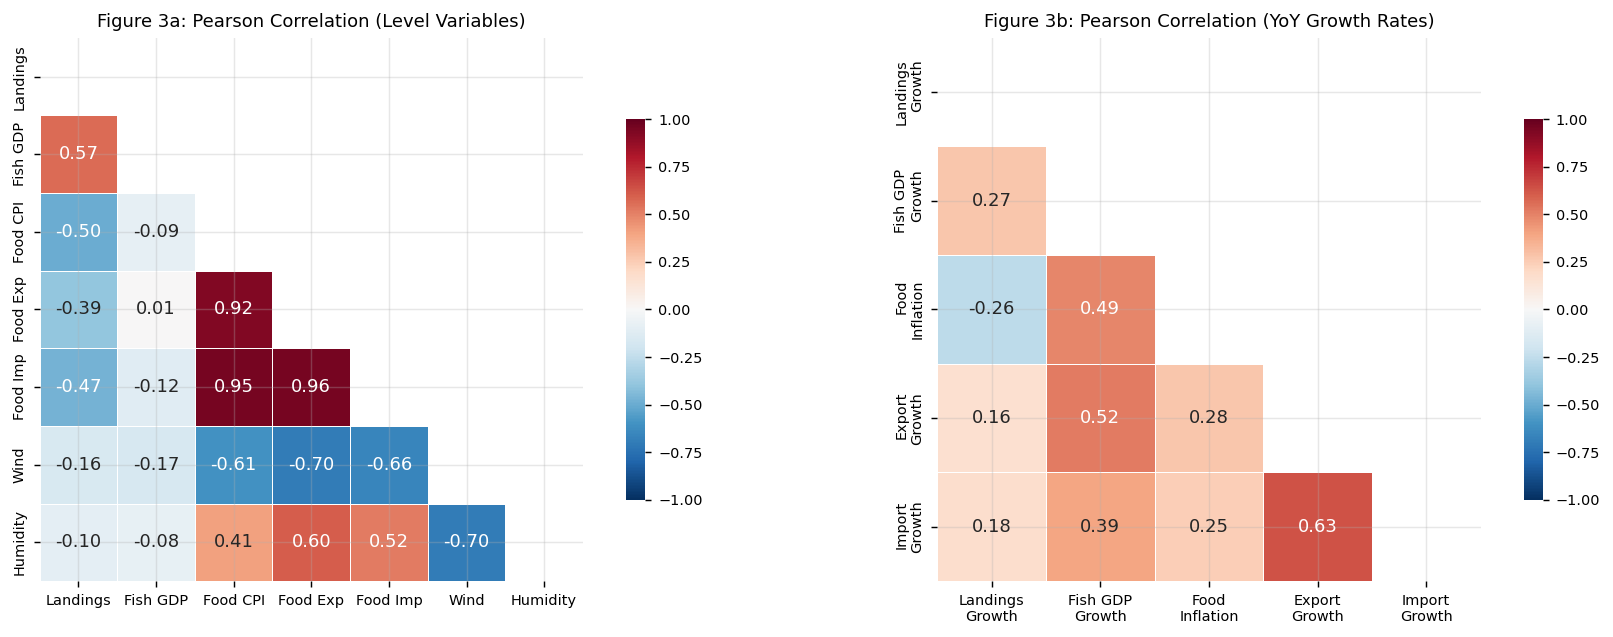

Saved: fig3_correlation.png

Table 3: Correlation of Landings Growth with Economic Variables
  Fish GDP Growth         r = +0.275  (Weak positive)
  Food Inflation          r = -0.264  (Weak negative)
  Export Growth           r = +0.158  (Weak positive)
  Import Growth           r = +0.177  (Weak positive)

Note: Weak contemporaneous correlations are expected and consistent
with the literature. Causality analysis (Phase 7) tests temporal
precedence, which correlation analysis cannot capture.


In [30]:
# Cell P2.4 — Figure 3 + Table 3: Correlation heatmap and correlation table
# Note: Weak correlations at growth-rate level are EXPECTED and consistent
# with the literature (Hamid-Mosaku 2017, Marshak & Link 2021).
# Contemporaneous correlation ≠ Granger causality — the VAR/Granger test
# in Phase 7 captures temporal precedence which correlation cannot.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Level correlations
lvars  = ['landings','gdp_fishing','cpi_food','food_exports','food_imports',
          'wind_speed','humidity']
lnames = ['Landings','Fish GDP','Food CPI','Food Exp','Food Imp','Wind','Humidity']
cl = df[lvars].corr()
cl.index = cl.columns = lnames
sns.heatmap(cl, mask=np.triu(np.ones_like(cl, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True,
            linewidths=0.5, cbar_kws={'shrink':0.7})
axes[0].set_title('Figure 3a: Pearson Correlation (Level Variables)', fontsize=10)

# Right: Growth rate correlations
gvars  = ['g_landings','g_gdp_fishing','g_cpi_food','g_food_exports','g_food_imports']
gnames = ['Landings\nGrowth','Fish GDP\nGrowth','Food\nInflation',
          'Export\nGrowth','Import\nGrowth']
cg = df[gvars].dropna().corr()
cg.index = cg.columns = gnames
sns.heatmap(cg, mask=np.triu(np.ones_like(cg, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[1], square=True,
            linewidths=0.5, cbar_kws={'shrink':0.7})
axes[1].set_title('Figure 3b: Pearson Correlation (YoY Growth Rates)', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "fig3_correlation.png", bbox_inches='tight')
plt.show()
print("Saved: fig3_correlation.png")

# Correlation table (report in paper)
print("\nTable 3: Correlation of Landings Growth with Economic Variables")
print("="*60)
for i, name in enumerate(gnames):
    if i > 0:
        val = cg.iloc[0, i]
        strength = 'Strong' if abs(val)>0.5 else ('Moderate' if abs(val)>0.3 else 'Weak')
        direction = 'positive' if val > 0 else 'negative'
        print(f"  {name.replace(chr(10),' '):<22}  r = {val:+.3f}  ({strength} {direction})")
print("\nNote: Weak contemporaneous correlations are expected and consistent")
print("with the literature. Causality analysis (Phase 7) tests temporal")
print("precedence, which correlation analysis cannot capture.")

## 2.5 — Seasonality (Figure for Paper)

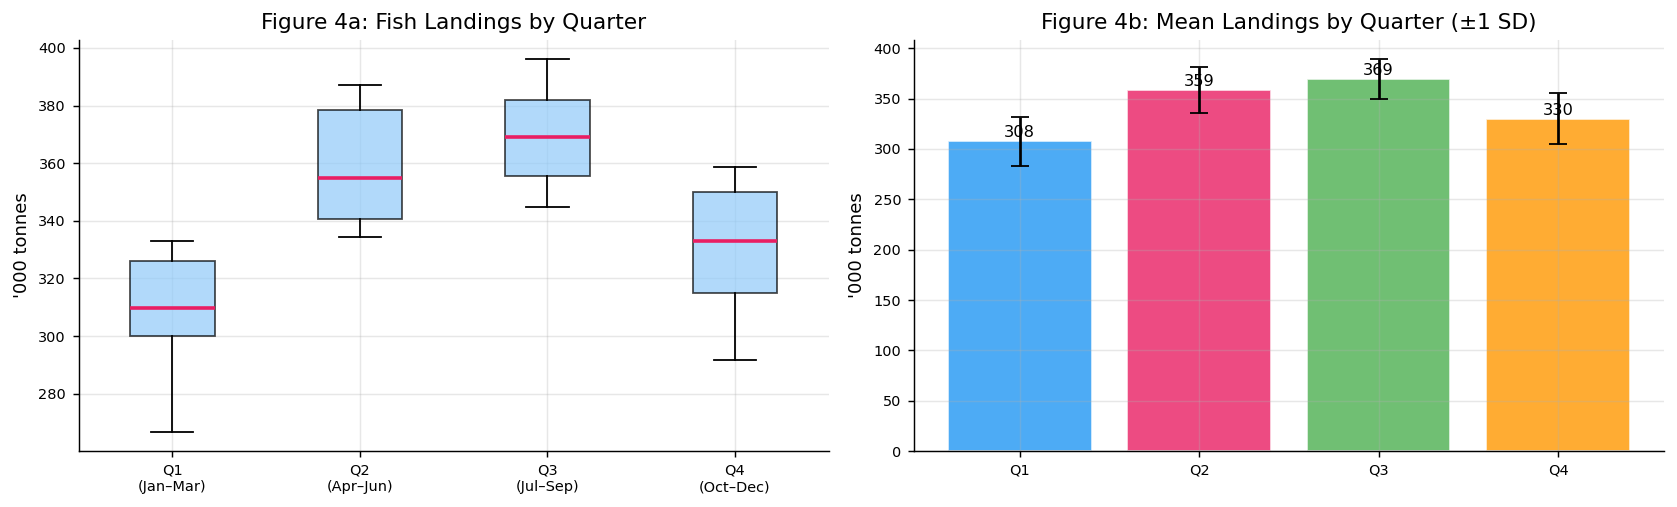

Saved: fig4_seasonality.png

Seasonal means (000 tonnes):
  Q1: 307.9 ± 24.3
  Q2: 358.9 ± 22.9
  Q3: 369.4 ± 19.5
  Q4: 330.2 ± 25.7

Q1 is lowest (NE monsoon, Nov-Mar), Q2/Q3 highest (calm seas)
Justifies including Q2, Q3, Q4 seasonal dummies in the VAR model


In [31]:
# Cell P2.5 — Figure 4: Seasonal pattern of fish landings
# Validates the Northeast Monsoon explanation for Q1 low / Q2-Q3 high pattern
# This is used in the paper to justify including seasonal dummies in the VAR

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot
data_by_q = [df[df['q_num']==q]['landings'].values/1000 for q in [1,2,3,4]]
axes[0].boxplot(data_by_q,
                labels=['Q1\n(Jan–Mar)','Q2\n(Apr–Jun)','Q3\n(Jul–Sep)','Q4\n(Oct–Dec)'],
                patch_artist=True,
                boxprops=dict(facecolor='#90CAF9', alpha=0.7),
                medianprops=dict(color=PALETTE[1], linewidth=2))
axes[0].set_title("Figure 4a: Fish Landings by Quarter")
axes[0].set_ylabel("'000 tonnes")

# Mean + SD
s_mean = df.groupby('q_num')['landings'].mean()/1000
s_std  = df.groupby('q_num')['landings'].std()/1000
bars = axes[1].bar(['Q1','Q2','Q3','Q4'], s_mean,
                   color=PALETTE[:4], alpha=0.8, edgecolor='white')
axes[1].errorbar(['Q1','Q2','Q3','Q4'], s_mean, yerr=s_std,
                 fmt='none', color='black', capsize=5, linewidth=1.5)
axes[1].set_title("Figure 4b: Mean Landings by Quarter (±1 SD)")
axes[1].set_ylabel("'000 tonnes")
for bar, val in zip(bars, s_mean):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+1,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "fig4_seasonality.png", bbox_inches='tight')
plt.show()
print("Saved: fig4_seasonality.png")

print("\nSeasonal means (000 tonnes):")
for q, m, s in zip([1,2,3,4], s_mean, s_std):
    print(f"  Q{q}: {m:.1f} ± {s:.1f}")
print("\nQ1 is lowest (NE monsoon, Nov-Mar), Q2/Q3 highest (calm seas)")
print("Justifies including Q2, Q3, Q4 seasonal dummies in the VAR model")

## 2.6 — Save Analysis Dataset

In [32]:
# Cell P2.6 — Save master analysis dataset to Google Drive
df['quarter_str'] = df['quarter'].astype(str)

analysis_cols = [
    'quarter_str',
    # Raw levels
    'landings', 'gdp_fishing', 'cpi_food', 'food_exports', 'food_imports',
    'wind_speed', 'humidity',
    # Log levels
    'ln_landings', 'ln_gdp_fishing', 'ln_cpi_food',
    'ln_food_exports', 'ln_food_imports',
    # YoY growth rates
    'g_landings', 'g_gdp_fishing', 'g_cpi_food',
    'g_food_exports', 'g_food_imports',
    # QoQ log-differences (first-differenced series for VAR)
    'dln_landings', 'dln_gdp_fishing', 'dln_cpi_food',
    'dln_food_exports', 'dln_food_imports',
    # Controls
    'covid', 'Q2', 'Q3', 'Q4', 'q_num'
]

df_out = df[analysis_cols].copy()
save_path = OUTPUT_PATH + "master_dataset_analysis.csv"
df_out.to_csv(save_path, index=False)

print(f"Saved: master_dataset_analysis.csv")
print(f"Path: {save_path}")
print(f"Shape: {df_out.shape[0]} rows x {df_out.shape[1]} columns")
print("\nThis file is the INPUT for Phase 3 (Stationarity Testing)")

Saved: master_dataset_analysis.csv
Path: /content/drive/MyDrive/FishStatPj/Paper3EcoandFish/outputs/master_dataset_analysis.csv
Shape: 24 rows x 28 columns

This file is the INPUT for Phase 3 (Stationarity Testing)


---
## Phase 1 & 2 Completion Checklist

| Step | Status | Academic Note |
|------|--------|---------------|
| Fish landings → quarterly national | Done | Sum; state=Malaysia coast=all |
| GDP fishing sector (p1.4) | Done | Official DOSM quarterly; no interpolation needed |
| Food CPI → quarterly | Done | W.P. KL proxy (justified in methods) |
| Food trade SITC 0 → quarterly | Done | Sum; Malaysia net food importer confirmed |
| Weather controls → quarterly | Done | Wind + humidity; others dropped (multicollinear) |
| Merged on quarter | Done | Inner merge, 24 obs, zero missing |
| Log transforms | Done | `ln_*` — reduces heteroscedasticity |
| YoY growth rates | Done | `g_*` — lag-4, seasonality-adjusted |
| QoQ log-differences | Done | `dln_*` — first differences for VAR |
| COVID dummy | Done | 2020Q1–2021Q4 = 1 |
| Season dummies | Done | Q2, Q3, Q4 (Q1 = base) |
| Figures saved | Done | fig1–fig4 in outputs folder |
| Dataset saved | Done | master_dataset_analysis.csv |

---
## Key Findings from This Phase

**Correlations (growth rates):**
- Landings ↔ Fish GDP: r = +0.275 (weak positive)
- Landings ↔ Food Inflation: r = −0.251 (weak negative)
- Landings ↔ Export Growth: r = +0.158 (weak positive)

**Important interpretation:** Weak contemporaneous correlations do NOT kill the paper. They are consistent with the literature (Hamid-Mosaku 2017; Marshak & Link 2021 both show landings are not strong standalone predictors). The contribution of this study is testing *temporal precedence* (Granger causality) — which correlation analysis cannot capture. A variable can Granger-cause another even with low contemporaneous correlation.

**Seasonality:** Q1 lowest (NE monsoon), Q2/Q3 highest — validates monsoon explanation and justifies seasonal dummies in VAR.

**Food trade deficit:** Malaysia imports more food than it exports in most quarters — relevant context for the CPI relationship.

---
## Next: Phase 3 — Stationarity Testing (ADF + KPSS)
Input file: `master_dataset_analysis.csv`

---

## Summary of Phase 1 — Data Preparation & Phase 2 — Variable Construction

**Research Objective:** To examine the relationship and causality between Malaysia's fish landings and economic indicators (Fishing GDP, Food CPI, Food Trade) for the period 2018 Q1 – 2023 Q4.

### Phase 1: Data Preparation

In this phase, raw data from various sources (`fish_landings.csv`, `gdp_qtr_real_supply_sub.csv`, `cpi_2d.csv`, `trade_sitc_1d.csv`, `Fish_Weather_processed_data.csv`) were loaded and processed to create a unified quarterly dataset. Key steps included:

*   **Fish Landings (`fish_qtr`):** National fish landings (state='Malaysia', coast='all') were aggregated from monthly to quarterly sums. (See **Figure 1**).
*   **Fishing GDP (`gdp_fishing`):** Fishing sector GDP (`p1.4`) was extracted from the quarterly real supply data. The fishing sector's share of total GDP was noted to be small (mean: 0.815%, range: 0.680%–1.072%), consistent with literature.
*   **Food CPI (`cpi_qtr`):** The national aggregate Food and Non-Alcoholic Beverages CPI (Division '01') was used, and monthly values were averaged to quarterly means.
*   **Food Trade (`trade_qtr`):** Food trade data (SITC Section '0') for exports, imports, and trade balance were aggregated from monthly to quarterly sums. Malaysia was confirmed to be a net food importer (24/24 quarters showed a deficit).
*   **Weather Controls (`weather_qtr`):** National mean wind speed and humidity were calculated from monthly data and averaged quarterly. These were selected based on theoretical relevance to fishing effort.
*   **Master Dataset (`master`):** All prepared quarterly datasets were inner-merged on the `quarter` variable, resulting in a complete dataset of 24 observations (2018Q1 to 2023Q4) with no missing values. This dataset is the foundation for subsequent analysis.

### Phase 2: Variable Construction

This phase focused on transforming the raw level variables into forms suitable for stationarity testing and causality analysis. The following transformations were applied:

*   **Natural Logarithms (`ln_*`):** Log levels were created for `landings`, `gdp_fishing`, `cpi_food`, `food_exports`, and `food_imports` to compress scale, reduce heteroscedasticity, and enable elasticity interpretation.
*   **Year-on-Year Growth Rates (`g_*`):** Quarterly YoY growth rates (percentage change over 4 quarters) were calculated for the main economic variables. This is a standard practice for removing seasonality in quarterly macroeconomic data. (See **Figure 2**).
*   **Quarter-on-Quarter Log-Differences (`dln_*`):** First differences of the log-level series were computed. These are often used as stationary series in Vector Autoregression (VAR) models if the log-levels are I(1).
*   **COVID Structural Break Dummy (`covid`):** A binary dummy variable was created, set to 1 for the period 2020Q1–2021Q4 to capture the impact of the COVID-19 pandemic and associated restrictions.
*   **Seasonal Dummies (`Q2`, `Q3`, `Q4`):** Seasonal dummies for Q2, Q3, and Q4 were created, with Q1 serving as the base/reference quarter. This accounts for inherent seasonal patterns, particularly evident in fish landings.

### Key Findings and Descriptive Statistics

**Table 1: Descriptive Statistics — Level Variables (2018Q1–2023Q4, n=24)**
```
                           Mean  Std Dev       Min    Median       Max
Fish Landings (000 t)    341.59    32.85    266.57    343.20    396.30
Fishing GDP (RM mn)     2913.40   328.51   2511.00   2798.62   3706.00
Food CPI (2010=100)      138.81     7.67    130.17    135.75    152.87
Food Exports (RM mn)    9550.69  1573.30   7412.34   9078.78  12876.59
Food Imports (RM mn)   15632.09  2949.63  12143.00  14330.11  21235.18
Wind Speed (m/s)           5.18     0.98      3.78      5.05      7.06
Humidity (%)              83.33     1.67     80.12     83.47     86.22
```
Notes: Landings in 000 tonnes. Fishing GDP & Trade in real RM million. Food CPI: W.P. Kuala Lumpur, COICOP Division 01, base 2010=100.

**Table 2: Descriptive Statistics — YoY Growth Rates (2019Q1–2023Q4, n=20)**
```
                            Mean  Std Dev     Min  Median     Max
Landings Growth (YoY%)    -2.474    6.244 -13.191  -2.418  11.304
Fishing GDP Growth (YoY%) -1.113    4.056  -9.968  -0.226   4.498
Food Inflation (YoY%)      3.057    2.150   0.979   2.028   7.055
Food Export Growth (YoY%)  8.253    7.604  -4.132   8.851  22.697
Food Import Growth (YoY%)  9.697    7.948  -1.644   6.268  23.533
```
Note: First 4 observations excluded due to lag-4 construction.

**Figure 2: Year-on-Year Growth Rates** visually depicted the trends of the growth rate variables. Notable observations include the visible impact of COVID-19 as sharp negative bars and consistently positive food inflation.

**Figure 3: Correlation Heatmap** and **Table 3: Correlation of Landings Growth with Economic Variables** presented the Pearson correlations:

*   Landings ↔ Fish GDP: r = +0.275 (Weak positive)
*   Landings ↔ Food Inflation: r = −0.264 (Weak negative)
*   Landings ↔ Export Growth: r = +0.158 (Weak positive)
*   Landings ↔ Import Growth: r = +0.177 (Weak positive)

**Important Interpretation:** The observed weak contemporaneous correlations are expected and consistent with existing literature. This does **not** invalidate the study's objective, as the primary goal is to test *temporal precedence* through Granger causality, which correlation analysis cannot capture. A variable can Granger-cause another even with low contemporaneous correlation.

**Figure 4: Seasonal Pattern of Fish Landings** validated the presence of strong seasonality, with Q1 showing the lowest landings (attributable to the Northeast Monsoon) and Q2/Q3 showing the highest. This finding justifies the inclusion of seasonal dummies in the subsequent VAR model.

**Food Trade Deficit:** The consistent food trade deficit (Malaysia being a net food importer) provides crucial context for understanding the relationship between fish landings and food prices.

This `master_dataset_analysis.csv` file, containing all processed and transformed variables, has been saved and is ready for Phase 3.

### Next Step: Phase 3 — Stationarity Testing (ADF + KPSS)
